# 08. 이중차분법

<br>

#### 패널 데이터
- **시간에 따라 반복해서 관측되는 데이터 구조**
- **동일한 실험 대상을 여러 시간대에 걸쳐 관측하면 동일한 대상에 처치가 이루어지기 전과 후에 무슨 일이 일어나는지 알 수 있음**

    $\rightarrow$ **패널데이터는 랜덤화가 불가능할 때 인과효과를 식별할 수 있는 좋은 대안**

- **관측 데이터를 가지고 있고 관측되지 않은 교란 요인이 존재할 가능성이 높다면, 패널데이터 방법은 처치효과를 식별하는 좋은 해결책**


<br>

#### 데이터 구조
1. **횡단면 데이터 (Cross-Sectional Data)**
- 특정 시점에 여러 대상을 한 번만 관측한 데이터
- 시간의 흐름을 볼 수 없으며, 대상 간의 차이만 비교 가능
- 예) "2026년 2월 1일 기준, 우리 앱 사용자 1만 명의 연령대별 구매 금액"
    
    $\rightarrow$ 분석 포인트: "나이가 많을수록 많이 쓰는가?"와 같은 상관관계를 주로 관찰

<br>

2. **패널 데이터 / 종단 설계 (Panel / Longitudinal Data)**
- 동일한 대상을 여러 시간대에 걸쳐 반복적으로 추적 관측한 데이터
- **개별 대상의 변화 과정을 추적할 수 있어 인과추론에 가장 강력**
- 예) "A라는 고객이 1월, 2월, 3월에 각각 얼마를 썼는지 추적한 데이터"

    $\rightarrow$ 분석 포인트: "A 고객에게 쿠폰을 줬더니 다음 달 구매가 늘었는가?"처럼 개별 단위의 변화에 중점

<br>

3. **반복 횡단면 데이터 (Repeated Cross-Sectional Data)**
- 여러 시점에 걸쳐 데이터를 수집하지만, 매번 표본(대상)이 달라지는 데이터
    - 매달 다른 시민들을 대상으로 하는 '대통령 지지율 여론조사'가 대표적입니다.
- 집단 전체의 추세(Trend)는 알 수 있지만, 특정 개인의 변화는 알 수 없음
- 예) "매주 월요일마다 매장을 방문한 고객 100명을 무작위로 뽑아 실시한 만족도 조사" (이번 주에 응답한 사람과 다음 주에 응답한 사람은 다른 사람임)

    $\rightarrow$ 분석 포인트: "우리 매장의 전반적인 서비스 만족도가 지난달보다 올랐는가?"

<br>

4. **합동 횡단면 데이터 (Pooled Cross-Sectional Data)**
- 서로 다른 시기에 수집된 여러 횡단면 데이터를 하나의 커다란 데이터셋으로 합친 것을 의미
- 반복 횡단면 데이터를 분석하기 위해 하나로 묶은 상태라고 이해 가능
- 표본 크기가 커지므로 통계적 유의성을 확보하기 좋음
- 예) "2024년 고객 조사 데이터와 2025년 고객 조사 데이터를 합쳐서 2년간의 총체적인 고객 특성을 분석하는 경우"

    $\rightarrow$ 분석 포인트: 시간이 흐름에 따라 변수 간의 관계(예: 소득과 소비의 관계)가 달라졌는지 등을 확인

<br>

<hr>

<br>

## 08-01. 패널데이터
- 패널데이터를 이해하기 위해, 마케팅 분야에서의 인과추론 적용 사례가 적절한 사례
- 마케팅 에서 무작위 실험을 진행하기는 쉽지 않으며, 마케팅에서 누가 광고(처치)를 보는지 통제할 수 없기 때문

    $\rightarrow$ 만약 새로운 사용자가 사이트를 방문하거나 다운로드할 때, 그 사용자가 캠페인을 보고 방문했는지 아니면 다른 이유로 방문했는지 알 수 없음

    $\rightarrow$ 고객이 마케팅 링크 중 하나를 클릭해서 제품을 구입했다는 사실을 알더라도, 해당 마케팅 링크가 없었다면 구입하지 않았을 고객인지는 알기 어려움

    - 예) 어느 고객이 구글 검색 상단에 나오는 스폰서(광고)를 클릭했다고 가정

        - **고객이 정말 그 제품을 원하는 상태였다면, 스폰서 링크가 없었다고 해도 스크롤을 조금 내려서 일반 링크를 클릭하여 해당 제품을 구입했을 수도 있음**

<br>

- 온라인보다 오프라인 마케팅에서의 인과효과 추정은 더 까다로움
    
    예) 도시에 광고판을 몇 개 배치해야 광고판 설치 비용을 초과하는 이익을 얻을 수 있는가?

    $\rightarrow$ 지역 실험 (Geo-Experiment) : 특정 지역에서 마케팅 캠페인을 집행하고, 이를 마케팅하지 않은 다른 지역과 비교

    $\rightarrow$ 여러 시간대에 걸쳐 전체 지역(실험 대상)의 데이터를 수집할 수 있기 때문

<br>

- 패널데이터는 여러 시간대 $t$에 걸친 여러 실험 대상 $i$가 존재
- 일부 온라인 웹사이트에서 실험 대상은 사람이고 $t$는 날짜(일 또는 월)일 수 있지만, 실험대상이 반드시 개별적인 고객일 필요는 없음

    오프라인 마케팅 캠페인에서 $i$는 제품 광고판을 설치한 도시가 될 수 있음

In [1]:
from toolz import *

import pandas as pd
import numpy as np

import statsmodels.formula.api as smf

import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib

from cycler import cycler

color=['0.0', '0.4', '0.8']
default_cycler = (cycler(color=color))
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

plt.rc('axes', prop_cycle=default_cycler)

<br>

- **데이터에서 관심있는 결과변수 $Y$는 다운로드 수 `downloads`**
    
    **$t$는 시간, $D$는 처치변수**

- **패널데이터에서는 처치를 개입이라고 명명**

<br>

- 마케팅 팀은 $D_i=1$인 도시에서 오프라인 캠페인을 진행
- 시간 차원에서 $T$는 기간의 수를, $T_{pre}$는 개입 이전 기간을 의미
    
    $\rightarrow$ 시간 벡터는 $t=[1, 2,  \dots, T_{pre}, T_{pre}+1, \dots, T]$
    
    - 처치 후 기간인 $T_{pre}+1 \dots, T$는 개입 후 (Post Intervention)

- `post` : 처치 이후 $t > T_{pre}$일 때 1, 그렇지 않으면 0

<br>

- 데이터셋에는 처치효과를 나타내는 $\tau$변수도 포함 $\rightarrow$ 즉, 시뮬레이션 데이터이기 때문에, 실제 처치효과를 알고 있다고 가정

    **하지만, 실제 데이터를 다룰 때 $\tau$를 관측할 수는 없음**

In [2]:
import pandas as pd
import numpy as np

mkt_data = (pd.read_csv("./data/short_offline_mkt_south.csv").astype({"date":"datetime64[ns]"}))
mkt_data.head()

,date,city,region,treated,tau,downloads,post
0,2021-05-01,5,S,0,0.0,51.0,0
1,2021-05-02,5,S,0,0.0,51.0,0
2,2021-05-03,5,S,0,0.0,51.0,0
3,2021-05-04,5,S,0,0.0,50.0,0
4,2021-05-05,5,S,0,0.0,49.0,0


<br>

- 개입은 개입 후 기간 ($t>T_{pre}$)의 실험군 $D=1$에만 발생
- 처치변수 및 개입 후에 대한 조합은 $W = D \times \mathbb{1} (t > T_{pre})$ 또는 $W = D\times Post$로 표기
- 개입 전 기간은 2021-05-01 ~ 2021-05-15이고, 개입 후 기간은 2021-05-15부터 2021-06-01

In [3]:
mkt_data.assign(w = lambda d: d["treated"]*d["post"]).groupby(["w"]).agg(min = ('date', 'min'), max = ('date', 'max'))

,min,max
w,,
0,2021-05-01,2021-06-01
1,2021-05-15,2021-06-01


<br>

- 처치 받은 도시들에서 오프라인 마케팅 캠페인 집행 후에 미친 영향을 이해
    
    ATT식은 캠페인 시작 후 ($t > T_{pre}$), 캠페인이 $D=1$ 도시들에 캠페인이 미친 영향을 이해하는 데 초점

$$
ATT = E[Y_{it}(1) - Y_{it}(0) | D = 1, t > T_{pre}]
$$

- **데이터에서 $Y_{it}(1)$은 관측 가능하므로, ATT의 추정은 누락된 잠재적 결과 $E[Y(0)|D=1, Post=1]$을 대체함으써 진행**

<br>

- 관측된 결과를 실험 대상-시간 행렬로 표현
    - **개입 후 기간의 실험군에서만 $Y(1)$을 관측할 수 있고, 그 외 3개의 셀에는 $Y(0)$을 관측할 수 있음**
    - **이 3개의 셀을 통해서 누락된 잠재적 결과인 $E[Y(0)|D=1, t > T_{pre}]$를 추정할 수 있으며,** 
        
        **누락된 잠재적 결과를 구하기 위해, 개입 후 기간의 대조군 결과를 사용하여 실험 대상 간의 상관관계를 활용할 수 있으며**

        **개입 전 기간의 실험군 결과를 사용하여 시간 간 상관관계를 활용할 수 있음**


* **시간 간 상관관계**: 실험군/대조군 각각의 시계열적인 변화 흐름을 추적
* **실험 대상 간 상관관계**: 같은 시점에 처치 여부에 따른 집단 간의 차이를 비교
* **추정 경로 (▲)**: '개입 전 실험군'의 값과 '대조군의 변화량'을 결합하여, 실험군이 처치를 받지 않았을 경우의 잠재적 결과($Y(0)$)를 역으로 추정해내는 경로

<br>

| 구분 | 개입 전 ($t < T_{pre}$) |  | 개입 후 ($t > T_{pre}$) |
| :--- | :---: | :---: | :---: |
| **실험군 ($D=1$)** | $Y(0)$ | **시간 간 상관관계** **$\rightarrow$** | **$Y(1)$** |
|  |  | | **실험 대상 간 상관관계** **$\uparrow$** |
| **대조군 ($D=0$)** | $Y(0)$ |  | $Y(0)$ |

<br>

#### 실험군의 반사실 $Y(0)$ 추정 (ATT가 쉬운 이유)
- 실험군이 처치를 받지 않았을 경우인 **$Y(0)$** 을 예측하기 위해 우리는 **3개의 데이터 포인트**를 참고 가능

| 구분 | 개입 전 ($t < T_{pre}$) | 개입 후 ($t > T_{pre}$) |
| :--- | :---: | :---: |
| **실험군 ($D=1$)** | **[힌트 1] $Y(0)$** | **[목표] $Y(0)$ 추정** |
| **대조군 ($D=0$)** | **[힌트 2] $Y(0)$** | **[힌트 3] $Y(0)$** |

* **힌트 1 (시간 간 상관관계)**: 실험군 본인의 과거 데이터를 통해 기본 수준(Baseline)을 파악함.
* **힌트 2 & 3 (실험 대상 간 상관관계)**: 대조군의 과거와 현재를 비교하여 시간에 따른 자연스러운 변화량(Trend)을 파악함.
* **결론**: 주변이 온통 $Y(0)$ 데이터로 둘러싸여 있어, 이를 조합해 **정교한 가짜 $Y(0)$** 을 만들기가 매우 수월

<br>

#### 대조군의 반사실 $Y(1)$ 추정 (ATC가 어려운 이유)
- 반대로, 처치를 안 받은 대조군이 처치를 받았을 경우인 **$Y(1)$** 을 예측하려면 참고할 데이터가 **단 1개**

| 구분 | 개입 전 ($t < T_{pre}$) | 개입 후 ($t > T_{pre}$) |
| :--- | :---: | :---: |
| **실험군 ($D=1$)** | $Y(0)$ | **[유일한 힌트] $Y(1)$** |
| **대조군 ($D=0$)** | $Y(0)$ | **[목표] $Y(1)$ 추정** |

* **문제점**: 전체 행렬을 통틀어 **$Y(1)$이라는 값은 '개입 후 실험군' 셀에만 유일**하게 존재
* **정보 부족**: 대조군 본인의 과거 데이터도 $Y(0)$, 현재 데이터도 $Y(0)$입니다. 처치($T=1$)로 인해 발생하는 변화를 예측할 근거가 오직 실험군 한 그룹의 사례
* **결론**: 참고할 표본이 너무 적어 추정의 신뢰도가 낮으며, 실험군과 대조군의 성격이 조금이라도 다르면 예측이 완전히 빗나갈 수 있음

<br>

<hr>

<br>

<br>

## 08-02. 표준 이중차분법 (Difference-in-Differences)

- **처치를 받은 실험군이, 만약 처치를 받지 않았더라면(반사실) 가졌을 잠재적 결과**
- **DID는 **실험군($D=1$)** 에게 일어난 변화에서 처치의 순수 효과만 발라내는 것**
    - **관측된 것**: 처치를 받은 실험군의 현재 모습 ($Y(1)$)
    - **필요한 것**: 처치를 안 받았을 때의 실험군 모습 (반사실적 $Y(0)$)
    
    $\rightarrow$ **DID 추정값 ($ATT$): 실제 관측된 Y(1) - 추정한 반사실적 Y(0)**

    $\rightarrow$ **DID의 목표: "대조군이 변하는 것을 보니, 처치를 안 받았으면 이 정도($Y(0)$)? 근데 실제로는 ($Y(1)$)? 그렇다면 그 차이가 증분(ATT)** 
    
    $\rightarrow$ **관측된 실험군의 결과($Y_1$)** 를 **추정된 반사실적 결과($Y_0$)** 와 비교하여 처치의 순수 증분 효과인 **ATT(Average Treatment Effect on the Treated)** 를 도출하는 것 
    

<br>

- **이중차분법 (DID)의 기본 개념은 관측된 실험군 기준값에 대조군 결과 추세를 보정하여, 누락된 잠재적 결과인 $E[Y(0)|D=1, Post=1]$를 추정하는 것**

$$
E[Y(0)|D=1, Post=1] = \underbrace{E[Y|D=1, Post=0]}_{\text{실험군 기준값}} + \underbrace{(E[Y|D=0, Post=1] - E[Y|D=0, Post=0])}_{\text{대조군의 자연적인 변화량 (Trend, 결과 추세)}}
$$

- **$E[Y(0)|D=1, Post=1]$을 추정할 때, 오른쪽의 기댓값을 표본평균으로 대체할 수 있음**
- **$E[Y(0)|D=1, Post=1]$에 대한 식을 ATT에 대입하면, 차이의 차이 (Difference In Difference)를 구할 수 있음 $\rightarrow$ DID 추정량**

$$
ATT = (E[Y|D=1, Post=1] - E[Y|D=1, Post=0]) - (E[Y|D=0, Post=1] - E[Y|D=0, Post=0])
$$

<br>

#### DID 추정값의 도출 과정
1. **데이터 기간을 개입 전과 개입 후로 구분**
2. **실험 대상을 실험군과 대조군으로 구분**
3. **4개의 셀 (개입 전 실험군/대조군, 개입 후 실험군/대조군) 모두의 평균을 계산**

In [4]:
did_data = mkt_data.groupby(["treated", "post"]).agg({"downloads":"mean", "date": "min"})
did_data

downloads       date
treated post                      
0       0     50.335034 2021-05-01
        1     50.556878 2021-05-15
1       0     50.944444 2021-05-01
        1     51.858025 2021-05-15

- 실험군의 기준값인 $E[Y|D=1, Post=0]$에 대해 

In [5]:
did_data.loc[1].loc[0, "downloads"], did_data.loc[0].diff().loc[1, "downloads"]

(np.float64(50.94444444444444), np.float64(0.22184429327285926))

In [6]:
y0_est = (did_data.loc[1].loc[0, "downloads"] # 실험군 기준값
          + did_data.loc[0].diff().loc[1, "downloads"]) # 대조군 추세

- 개입 후 기간의 실험군 평균 결과에서 반사실 추정값을 뺀 ATT 추정

In [7]:
att = did_data.loc[1].loc[1, "downloads"] - y0_est
att

np.float64(0.6917359536407233)

- 실험군과 개입 후 기간을 필터링하여 이 값을 실제 ATT와 비교하면, DID 추정량이 실제 ATT와 비슷한 것을 확인 가능

In [8]:
mkt_data.query("post==1").query("treated==1")["tau"].mean()

np.float64(0.7660316402518457)

<br>

### 01. 이중차분법과 결과 변화

- **원래 데이터가 (실험대상 X 날짜)의 형태였다면, $\Delta y$는 각 실험대상별 전후 차이**

    $\rightarrow$ **실험 대상 $i$에 대한 시간 경과에 따른 결과의 차이를 $\Delta y_i = E[y_i | t>T_{pre}] - E[y_i|t \leq T_{pre}]$**

In [9]:
pre = mkt_data.query("post==0").groupby("city")["downloads"].mean()
post = mkt_data.query("post==1").groupby("city")["downloads"].mean()

delta_y = ((post - pre)
           .rename("delta_y")
           .to_frame()
           # add the treatment dummy
           .join(mkt_data.groupby("city")["treated"].max()))

delta_y.tail()

,delta_y,treated
city,,
192,0.555556,0
193,0.166667,0
195,0.420635,0
196,0.119048,0
197,1.595238,1


<br>


- **이중차분법은 $\Delta y_0$를 대조군 평균으로 대체하여 ATT를 식별**

    $\rightarrow$ **이중차분법은 각 집단의 시간적 변화량을 비교함으로써 외생적 요인을 통제**

$$
ATT = E[\Delta y | D=1] - E[\Delta y | D=0] = \underbrace{E[y_{post} - y_{pre} \mid D=1]}_{\text{실험군 변화량}} - \underbrace{E[y_{post} - y_{pre} \mid D=0]}_{\text{대조군 변화량}}
$$


    


In [10]:
(delta_y.query("treated==1")["delta_y"].mean() - delta_y.query("treated==0")["delta_y"].mean())

np.float64(0.6917359536407155)

<br>

- **시간에 따라 관측된 실험군 및 대조군 결과와 추정된 실험군의 반사실적 결과를 함께 시각화**
    
    $E[Y(0)|D=1]$의 DID 추정값은 점선으로 표시
    
    **추정된 ATT는 처치 후 기간에 추정된 반사실적 결과 $Y(0)$와 관측된 결과 $Y(1)$의 차이 (점자 $x$자 표시의 차이)**

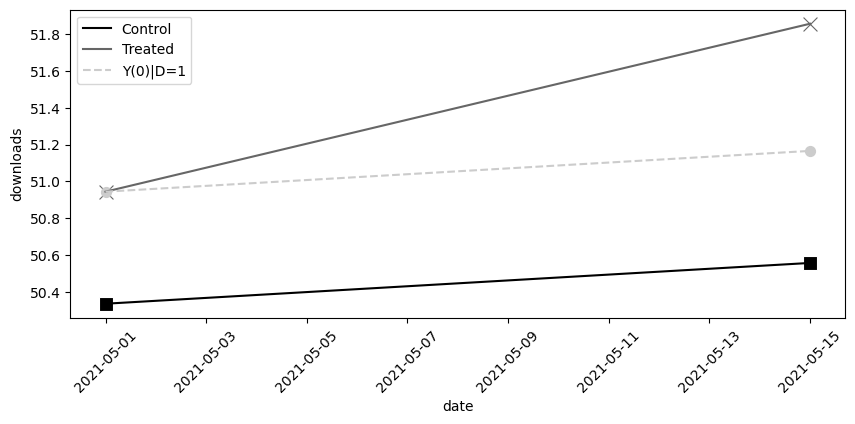

In [11]:
did_plt = did_data.reset_index()

plt.figure(figsize=(10,4))

sns.scatterplot(data=did_plt.query("treated==0"), x="date", y="downloads", s=100, color="C0", marker="s")
sns.lineplot(data=did_plt.query("treated==0"), x="date", y="downloads", label="Control", color="C0")

sns.scatterplot(data=did_plt.query("treated==1"), x="date", y="downloads", s=100, color="C1", marker="x")
sns.lineplot(data=did_plt.query("treated==1"), x="date", y="downloads", label="Treated", color="C1",)

plt.plot(did_data.loc[1, "date"], [did_data.loc[1, "downloads"][0], y0_est], color="C2", linestyle="dashed", label="Y(0)|D=1")
plt.scatter(did_data.loc[1, "date"], [did_data.loc[1, "downloads"][0], y0_est], color="C2", s=50)

plt.xticks(rotation = 45);
plt.legend()
plt.show()

<br>

### 02. 이중차분법과 OLS
- **포화회귀모델 (Saturated Regression Model)을 사용하여 앞서 구했던 것과 같은 DID 추정량**

1. 일별 데이터를 도시와개입 전후 기간별로 그룹화
2. 각 도시와 기간 조합의 일평균 다운로드 수를 계산
3. 각 기간의 시간 날짜와 각 도시의 처치 여부도 함께 확인

In [12]:
did_data = (mkt_data
            .groupby(["city", "post"])
            .agg({"downloads":"mean", "date": "min", "treated": "max"})
            .reset_index())

did_data.head()

,city,post,downloads,date,treated
0,5,0,50.642857,2021-05-01,0
1,5,1,50.166667,2021-05-15,0
2,15,0,49.142857,2021-05-01,0
3,15,1,49.166667,2021-05-15,0
4,20,0,48.785714,2021-05-01,0


<br>

- **이 기간별 도시 데이터를 사용하여 다음 선형 모델을 추정**

$$
Y_{it} = \beta_0 + \beta_1 D_1 + \beta_2 Post_t + \beta_3 D_i Post_t + e_{it}
$$

- **$\hat{\beta_3}$는 DID 추정값**
- $\beta_0$는 개입 전의 대조군 기준점 
- $\beta_0+ \beta_1$은 개입 전의 실험군 기준점
- $\beta_1$은 실험군 도시와 대조군 도시간의 기준값 차이
- $\beta_0 + \beta_2$는 개입 후 대조군의 수준
- **$\beta_2$는 대조군의 추세이며, 이는 개입 전후 대조군이 얼마나 변했는지를 의미**

<br>

- **$\beta_1$은 개입에 따른 효과를 측정하기 위해 실험군과 대조군 간의 차이를 나타내는 것이고,** 
    
    **$\beta_2$는 시간이 지남에 따라 발생하는 개입 전후의 변화량**

    $\rightarrow$ **개입 후 실험군의 수준은 $\beta_0 + \beta_1 + \beta_2 + \beta_3$**

    - **여기서 $\beta_3$는 실험군과 대조군 간의 차이와 시간 추세를 모두 고려한 DID 추정량으로, 개입의 효과를 나타내는 증가분**

In [13]:
import statsmodels.formula.api as smf

In [14]:
smf.ols(
    'downloads ~ treated*post', data=did_data
).fit().params["treated:post"]

np.float64(0.6917359536407144)


<br>

### 03. 이중차분법과 고정효과 (Fixed Effect)
- **이중차분법을 바라보는 관점 중 하나는 고정효과모델 (Unit-Fixed Effect Model), 즉 이원고정효과 (TWFE)를 사용하는 것**  
    **이 모델에는 처치효과 $\tau$, 개별 대상과 시간 고정효과인 $\alpha_i$와 $y_i$가 각각 존재**

$$
Y_{it} = \tau W_{it} + \alpha_i + \gamma_t + e_{it}
$$

$$
W_{it} = D_i Post_t
$$

<br>

- 이 모델은 $W$와 관련된 매개변수 추정값이 DID 추정값과 일치하며, ATT 계산 가능
    - 이를 위해 더미변수를 사용하거나 데이터 평균을 제거하는 방식으로 고정효과를 추정 가능

<br>

- 도시 및 기간에 대한 더미변수를 `C(city)`와 `C(post)`로 포함
- 실험군 더미와 처치 이후 더미를 곱하여 $W$를 생성
    - `*` : 두 항 사이의 상호작용항과 각 변수에 대한 항을 생성
    - `:` : 두 항 사이의 상호작용항만 생성

In [15]:
m = smf.ols('downloads ~ treated:post + C(city) + C(post)', data=did_data).fit()

m.params["treated:post"]

np.float64(0.6917359536407073)

<br>

### 04. 이중차분법과 블록 디자인

<br>

#### DID의 데이터 구조적 제약 조건
- **개입 전/후 기간을 하나의 블록으로 집계하지 않음** : 데이터를 '전체 평균'하나로 취급하는 것이 아니라, 시계열의 흐름을 유지한 채 분석
    
    $\rightarrow$ 개입 전후의 추세가 일정한지 확인해야 하기 때문

    - **만약 전/후를 하나의 평균값으로 합쳐버리면 (Block Aggregation), 처치 직후에만 효과가 반짝 나타났다가 사라졌는지, 서서히 효과가 커졌는지 등의 역동적인 변동을 확인할 수 없음**

- **다른 시점에 개입이 이뤄지는 일은 허용되지 않음 : 순차적 도입 금지 (Staggered Adoption)**
    - **표준 DID의 설계 : 모든 실험군 대상자가 정확히 같은 날짜 $T_{pre}$ 이후에 동시에 처치를 받아야 함**
    - 허용되지 않는 예시:
        - A 음식점은 1월 1일부터 할인 시작

        - B 음식점은 1월 15일부터 할인 시작

        - C 음식점은 2월 1일부터 할인 시작

    $\rightarrow$ **'누가 대조군이고 누가 실험군인지'가 시간에 따라 계속 변하게 됨**


<br>

- **이중차분법의 블록 디자인 시각화**
    - 개입 후의 실험군과 대조군 간의 차이

In [16]:
import matplotlib.ticker as plticker

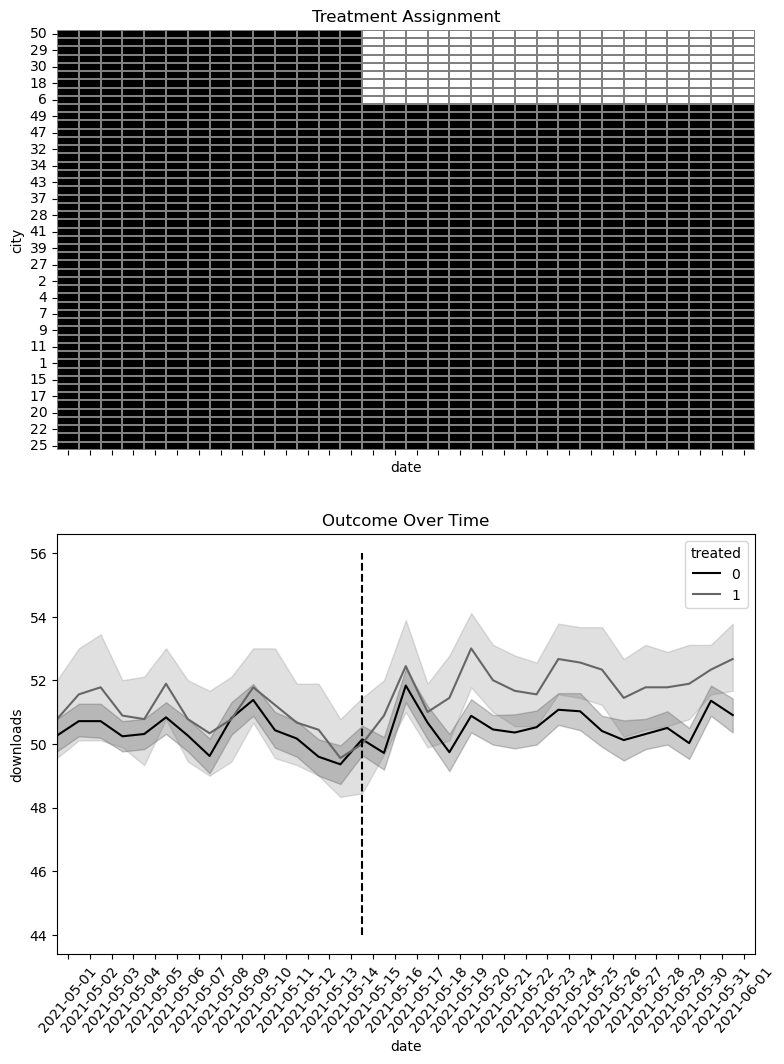

In [17]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(9, 12), sharex=True)

heat_plt = (mkt_data
            .assign(treated=lambda d: d.groupby("city")["treated"].transform("max"))      
            .astype({"date":"str"})
            .assign(treated=lambda d: d["treated"] * d["post"]) 
            .pivot(index="city", columns="date", values="treated") 
            .reset_index()
            .sort_values(max(mkt_data["date"].astype(str)), ascending=False)
            .reset_index()
            .drop(columns=["city"])
            .rename(columns={"index":"city"})
            .set_index("city"))

sns.heatmap(heat_plt, cmap="gray", linewidths=0.01, linecolor="0.5", ax=ax1, cbar=False)
ax1.set_title("Treatment Assignment")

sns.lineplot(data=mkt_data.astype({"date":"str"}),
             x="date", y="downloads", hue="treated", ax=ax2)

ax2.vlines("2021-05-15", mkt_data["downloads"].min(), mkt_data["downloads"].max(), 
           color="black", ls="dashed", label="Interv.")
ax2.set_title("Outcome Over Time")

plt.xticks(rotation = 50)
plt.show()

<br>

### 05. 추론
- 패널데이터에서의 추론은 까다로우며, 신뢰구간은 정확하지 않을 수 있음
    
    **$N \cdot T$개의 데이터포인트가 있지만, 동일한 실험 대상이 여러 번 나타나므로, 이들이 독립적이고 동일하게 분포 (IID)되지 않음**

- 처치는 시간대가 아닌 실험 대상에 배정되므로, 실제 표본 크기는 $N \cdot T$가 아니라, $N$에 불과

    **하지만 회귀분석은 표준오차를 계산할 때 표본 크기를 고려함**

    $\rightarrow$ **회귀분석의 표준오차를 보정하려면, 실험 대상별로 군집화**

<br>

- **군집표준오차 (Clustered Standard Error)은 기존 표준오차보다 신뢰구간이 더 넓음**
    - 군집표준오차의 사용은 데이터의 군집 내 상관관계를 고려함으로써 신뢰구간을 넓힘
    - 관측값들이 자연스럽게 형성된 군집 내에서 서로 상관되어있을 때, 표준오차를 보다 정확하게 추정하기위해 필요
    - 군집표준오차를 계산함으로써 군집 내의 변동성을 올바르게 반영하여, 전체 표본의 변동성 추정값을 조정 $\rightarrow$ 일반적으로 표준오차가 증가하고 신뢰구간이 넓어짐

In [22]:
# 군집 표준오차
m = smf.ols(
    'downloads ~ treated:post + C(city) + C(date)', data=mkt_data
).fit(cov_type='cluster', cov_kwds={'groups': mkt_data['city']})

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536406645


0    0.296101
1    1.087370
Name: treated:post, dtype: float64

In [23]:
m = smf.ols('downloads ~ treated:post + C(city) + C(date)', data=mkt_data).fit()

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536406645


0    0.478014
1    0.905457
Name: treated:post, dtype: float64

<br>

- 실험 대상과 처치 전후 기간별 집계한 데이터의 신뢰구간 $\rightarrow$ 신뢰구간이 더 넓어짐


In [28]:
m = smf.ols(
    'downloads ~ treated:post + C(city) + C(date)', data=did_data
).fit(cov_type='cluster', cov_kwds={'groups': did_data['city']})

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407073


0    0.138188
1    1.245284
Name: treated:post, dtype: float64

<br>

- **일반적인 부트스트랩은 모든 관측치(행)를 개별적으로 복원 추출**
    - 문제점: '서울'이라는 도시의 1월 데이터와 2월 데이터 사이의 **시간적 연결고리(상관성)**를 끊어버림
    - 결과: 데이터가 실제보다 훨씬 더 독립적이고 정보가 많은 것처럼 오해하여, 신뢰구간을 너무 좁게(과도하게 유의하게) 추정하는 오류

- **블록 부트스트랩(Block Bootstrap) : 데이터의 행 단위가 아니라, '실험 대상(도시, 블록)' 단위로 통째로 복원 추출**
    - 추출 방식: '서울'의 전체 시계열 데이터를 하나의 덩어리로 보고, 이 덩어리를 통째로 뽑음
    - 장점: 특정 도시 내부에 존재하는 시간적 상관관계나 오차항의 구조를 그대로 유지한 채 샘플링 $\rightarrow$ **군집 표준 오차(Clustered Standard Error)**를 부트스트랩 방식으로 구현

<br>

- 실험 대상을 복원추출하는 함수

In [29]:
def block_sample(df, unit_col):
    
    units = df[unit_col].unique()
    sample = np.random.choice(units, size=len(units), replace=True) 
    
    return (df
            .set_index(unit_col)
            .loc[sample]
            .reset_index(level=[unit_col]))

<br>

- 블록 부트스트랩 함수

In [33]:
from joblib import Parallel, delayed

In [31]:
def block_bootstrap(data, est_fn, unit_col, rounds=200, seed=123, pcts=[2.5, 97.5]):
    np.random.seed(seed)
    
    stats = Parallel(n_jobs=4)(
        delayed(est_fn)(block_sample(data, unit_col=unit_col))
        for _ in range(rounds))
    
    return np.percentile(stats, pcts)

<br>

- 데이터에 적용된 DID 추정량의 95% 신뢰구간
    - 블록 부트스트랩의 신뢰구간은 실험 대상별 군집표준오차를 사용하여 얻은 구간과 유사 $\rightarrow$ 블록 부트스트랩함수가 잘 작동한다는 것

In [32]:
def est_fn(df):
    m = smf.ols('downloads ~ treated:post + C(city) + C(date)', data=df).fit()
    return m.params["treated:post"]

block_bootstrap(mkt_data, est_fn, "city")

array([0.23162214, 1.14002646])

<br>

<hr>

<br>

## 08-03. 식별 가정
- 이중차분법이 통계적으로 유효하기 위해 반드시 충족되어야 하는 핵심 가정

<br>

### 01. 평행 추세 (Parallel Trends)

|분석 방식|필요 데이터|핵심 가정|가정의 강도|
| - | - | - | - |
|**집단 간 비교**|대조군 필요|교환 가능성: 실험군과 대조군은 무작위 할당처럼 완벽하게 동일하다. ($E[Y(0)∣D=1]=E[Y(0)∣D=0]$)|매우 강함|
|**전후 비교**|시간 차원 필요|정체성/불변성: 시간의 흐름에 따른 외부 요인의 영향이 전혀 없다. ($E[Y(0)t=1​∣D=1]=E[Y(0)t=0​∣D=1]$)|매우 강함|
|**이중차분 (DiD)**|둘 다 필요|**평행 추세: 실험군과 대조군이 '변화하는 속도(기울기)'가 같다.**|**상대적으로 약함**|

<br>

$$
E[Y(0)_{it=1} - Y(0)_{it=0}|D=1] = E[Y(0)_{it=1} - Y(0)_{it=0}|D=0]
$$

* **좌변**: 실험군이 처치를 안 받았을 때 겪었을 **가상의 변화량**
* **우변**: 대조군이 실제로 겪은 **관측된 변화량**

    $\rightarrow$ **처치가 없었더라면, 실험군이 변했을 정도는 대조군이 변한 정도와 같았을 것**

<br>

- 평행 추세 가정은 관측할 수 없는 항 $E[Y(0)_{it}=1|D=1]$이 포함되므로 검증할 수 없음


<br>

- 이중차분법(DiD)의 신뢰도는 **"점선(추정된 반사실)"** 이 **"회색 파선(실제 반사실)"** 과 얼마나 일치하느냐에 달려 있음

<br>

1. **평행 추세 만족 (첫 번째 그래프)상황: 대조군의 기울기와 실험군의 잠재적 $Y(0)$ 기울기가 일치함**
- 결과: 추정된 점선이 실제 반사실적 경로(회색 파선)와 겹침
- 결론: DiD 추정값($ATT$)이 실제 인과 효과와 정확히 일치

<br>

2. **추세 이탈 및 편향 (두 번째 그래프)**
- 상황: 실험군의 실제 잠재적 추세(회색 파선)가 대조군의 추세보다 완만함 (Diverging Trends)
- 문제: 대조군의 가파른 기울기를 그대로 실험군에 적용하다 보니, 추정된 점선($Y_0$)이 실제보다 높게 찍힘
- 결과: 실제 효과보다 작게 측정되는 하향 편향(Downward Bias) 발생
    
    "옆집은 급성장 중인데 우리 집은 원래 천천히 성장할 운명이었다면, 옆집 기준을 나에게 들이댔을 때 내 성과는 과소평가됨."

<br>

3. **척도 변환의 위험성 (세 번째 그래프)**
- 상황: 수준(Level) 데이터에서는 평행했던 추세가 **로그 변환(Log Scale)** 을 거치자 평행이 깨짐
- 핵심: DiD는 '가산적(Additive)' 평행을 가정함. 즉, "더해지는 양"이 같아야 함
- **주의: 효과를 백분율(%)로 보고 싶어 로그를 취하거나 비율로 변환하면, 원래 데이터에서 성립하던 평행 추세가 무너져 분석 결과가 오염될 수 있음**

<br>

- **DiD 분석 시 주의해야 할 '평행 추세'와 '척도'**

| 시나리오 | 추정 결과 | 분석적 시사점 |
| :--- | :--- | :--- |
| **Parallel Trends** | **정확함 (Unbiased)** | 대조군이 실험군의 반사실을 완벽히 대변함 |
| **Diverging Trends** | **편향 발생 (Biased)** | **개입 전 추세가 다르면 DiD 결과값을 신뢰할 수 없음** |
| **Scale Transformation** | **추세 왜곡 위험** | **로그 변환이나 백분율 변환 시 평행 추세 가정이 깨질 수 있음에 주의** |

<img src='img/parrallel-assumption.png' width=1200>


<br>

#### 평행 추세 가정과 독립성 가정
- **독립성 가정은 실험군과 대조군에서 평균적으로 $Y(0)$의 수준이 동일하다고 가정**하지만

    **평행 추세 가정은 실험군과 대조군 간 $Y(0)$의 추세가 동일하다고 가정**

|구분|독립성 가정 (Independence)|평행 추세 가정 (Parallel Trends) |
| - | - | -|
|핵심 전제|실험군과 대조군의 **결과 수준($Y_0$​)** 이 평균적으로 같다.|실험군과 대조군의 변화 추세($\Delta y_0$​)가 평균적으로 같다.
|수식 표현|$Y(0) \perp T$ | $(\Delta y_0, \Delta y_1) \perp T$
|주요 특징|주로 무작위 통제 실험(RCT)에서 요구되는 강력한 가정|처치가 무작위가 아니어도 반사실 추세만 같으면 ATT 식별이 가능
|데이터 요구|횡단면 데이터(Cross-sectional)로도 가능|**패널 데이터(Panel Data)** 가 필수적

<br>


####  조건부 평행 추세 가정 (Conditional Parallel Trends)
- **실제 데이터에서 실험군과 대조군의 추세가 처음부터 완벽히 평행하기는 어려움 $\rightarrow$ 공변량 $X$를 도입하여 가정을 완화 가능**

    $\rightarrow$ **"단순히 비교하면 추세가 다르지만, 특정 특성($X$, 예: 도시 규모, 업종 등)이 같다면 두 집단의 추세는 동일할 것이다."라는 가정**
    
- **이중차분법 모델에 $X$를 조건부로 추가함으로써, 통제되지 않은 변수로 인해 발생하는 추세의 차이를 제거하고 평행 상태를 강제로 만들수 있음**

<br>



<br>

### 02. 비기대 가정과 SUTVA
- **SUTVA (Stable Unit Treatment Value Assumption)**
    - **특정 실험 대상에게 나타난 결과가 오직 그 대상에게 가해진 처치에 의해서만 결정되어야 하며, 외부 요인에 의해 오염되지 않아야 함**
        - **상호 간섭 없음 (No Interference)** : 특정 대상 $i$가 받은 처치가 다른 대상 $j$의 결과에 영향을 주지 않아야 함
        - **단일한 처치** : 모든 실험군에게 제공되는 처치는 동일한 형태와 강도를 가져야 함

<br>

- 예) 블랙 프라이데이가 휴대폰 판매에 미치는 영향
    - 많은 회사가 블랙 프라이데이 할인을 할 예정이며, 블랙 프라이데이 이전 기간은 이미 고개들이 제품을 찾는 시기
    
    $\rightarrow$ 블랙 프라이데이(처치)가 되기도 전에 판매량이 급증하는 모습

    $\rightarrow$ **시간적 파급 효과뿐만 아니라 실험 대상의 파급 효과도 고려해야 하며, 패널데이터 분석에서 SUTVA를 만족시키는 것은 까다로움** (특히 실험 대상이 지리적 영역일 때)

<br>

#### 공간적 파급 효과
- 대조군이 실험군에 충분히 가깝다고 간주되면 값이 1인 더미변수 $S$를 사용하여, 이중차분법의 이원고정효과 공식을 확장

$$
Y_{it} = \tau_{it} W_{it} + \eta_0 S_i (1-W_{it}) + \eta_1 S_i W_{it} + \alpha_i + \gamma_t + e_{it}
$$
    

<br>

### 03. 강외생성 (Strict Exogeneity)
- **강외생성 가정은 보통 고정효과모델에서의 잔차에 대한 가정**

$$
Y_{it} = \alpha_i X_{it} \beta + \epsilon_{it}
$$

- 강외생성은 다음과 같이 수식으로 표현

$$
E[\epsilon_{it}|X_{it}, \alpha_i] = 0
$$

<br>

- **강외생성 가정은 더 강력한 가정이며 평행 추세를 내포**
1. 시간에 따라 변하는 교란 요인 없음
2. 피드백 없음
3. 이월 효과 (Carryover Effect) 없음

<br>

<br>

### 04. 시간에 따라 변하지 않는 교란 요인

<br>

- **패널데이터에서는 시간과 실험 대상의 상관관계를 활용할 수 있으며,** 
    
    **시간에 걸쳐 반복되는 관측값이 있다면, 관측되지 않는 교란 요인이 존재해도 인과효과를 식별할 수 있음**

    $\rightarrow$ **이 경우 해당 교란 요인이 시간에 따라 일정하다면 가능**

<br>

<img src='img/08DAG.png' width=600>

<br>

- 예) 각 도시에는 고유한 문화, 법률, 인구 등이 있으며, 이 모든 변수는 처치 및 결과변수에 큰 영향을 줄 수 있음
    
    $\rightarrow$ **문화와 법률 같은 일부 변수는 정량화하기 어려움 $\rightarrow$ 관측할 수 없는 교란 요인**

    $\rightarrow$ **실험 대상에 초점을 맞추고, 시간에 따른 대상의 변화를 추적함으로써, 시간에 걸쳐 고정된 모든 변수들을 통제하고 있음을 파악**

    $\rightarrow$ **즉, 측정되지 않은 시간 고정 (Time-fixed)공변량을 포함하는 것**

    (특정 도시의 다운로드 수가 증가하면, 이는 (적어도 단기적으로는) 도시 문화의 변화 때문이 아님 (해당 교란 요인이 시간에 따라 고정되어있기 때문))
    
<br>

- **시간 고정 교란 요인은 측정 불가능하므로 통제할 수 없음**

    **그럼에도 실험 대상 자체를 통제하면, 해당 교란 요인을 통과하는 백도어를 여전히 차단할 수 있음**

<br>

- **실험 대상 고정효과를 추가하는 방법은 더미변수를 추가하는 것 이외에, 평균을 제거 하는 방법 (실험 대상별 결과 및 처치변수의 평균을 계산하여 원래 변수에서 빼기)도 존재**

$$
\ddot{Y_{it}} = Y_{it} - \bar{Y_i}
$$

$$
\ddot{W_{it}} = W_{it} - \bar{W_i}
$$


<br>

- $D_i$는 시간에 고정된 변수이므로, $W_{it} = D_i Post_i$를 사용하여 처치변수를 표현
- 평균 제거 이후, 관측되지 않은 $U_i$는 모두 사라짐

    $U_i$는 시간에 걸쳐 일정하므로 $U_i = \bar{U_i}$가 디ㅗ고, 모든 곳에서 $\ddot{U_{it}} = 0$이 됨

    $\rightarrow$ 시럼 대상 고정효과는 시간에 걸쳐 일정한 변수를 모두 없애버림

<br>

- **실험 대상에 따라서는 고정되지만, 시간에 따라 변하는 변수를 없애는 시간 고정효과에 대해서도 비슷한 논리를 적용 가능** 
    
    $\rightarrow$ 국가의 환율, 인플레이션 등 전국적 변수는 모든 도시 (실험 대상)에서 동일



<br>

<br>

### 05. 피드백 없음 (No Feedback)

- **과거 결과인 $Y_{it-1}$에서 현재 처치인 $W_{it}$으로 향하는 화설표가 없음 $\rightarrow$ 피드백이 없음**
- **데이터의 독립성** : 처치 벡터 $W=(w_0, w_1, \dots, w_T)$는 과거 데이터의 흐름과 상관없이 사전에 계획되거나 외생적으로 결정되어야 함

- **만약 과거 결과가 처치를 결정하게 되면 (피드백), 처치 때문에 결과가 좋아진 것인지 ($W \rightarrow Y$), 결과가 좋아서 처치를 더 해준 것인지 ($Y\rightarrow W)$를 구분할 수 없게 됨**

- 예) 마케팅팀이 다운로드 수가 1,000건을 넘은 도시에만 마케팅 캠페인을 집행하기로 결정
    
    $\rightarrow$ 처치 $W$는 순수하게 외생적인 결정이 아니라, 과거 성적 $Y$에 종속된 결과물
    
    $\rightarrow$ 인과효과 ATT에 역인과관계에 의한 편향이 섞여 정확한 분석이 불가능


<br>



<br>

### 06. 이월 효과와 시차종속변수 없음
- 이월 효과 (Carryover Effect)의 처리
    - 어제 집행한 마케팅($W_{it-1}$)이 오늘 다운로드 수($Y_{it}$)에도 여전히 영향을 주는 현상
    - 수식에 처치 변수의 시차(Lag) 버전인 $W_{it-1}$을 추가하여 이 효과($\theta$)를 별도로 추정함으로써 가정을 완화할 수 있음

    ($\theta$가 이월 효과의 크기)

$$
Y_{it} = \tau_{it} W_{it} + \theta W_{it-1} + \alpha_i + \gamma_i + e_{it}
$$ 

<br>

- **시차종속변수 (Lagged Dependent Variable, LDV) 없음**
    - 어제의 다운로드 수 ($Y_{it-1}$)가 오늘의 다운로드 수 ($Y_{it}$)를 직접적으로 결정짓는 원인이 아니라는 가정
    - 이 가정은 DID에서 필수적이지 않음 $\rightarrow$ 과거 결과에서 현재 결과로 화살표를 추가하더라도, DID의 기본 식별 방법에는 큰 영향을 주지 않기 때문

<br>

<br>

<hr>